# TextCNN Ablation: 3 Dataset Variants

Compare TextCNN topic classifier across 3 dataset preparation strategies:

| Dataset | Merge | Split | Embedding |
|---------|-------|-------|----------|
| A (k=2) | bottom-2 (Sec&Def + Ind/Res/Env) | strat=domain\|\|qtype | shared_embedding_artifacts_ab |
| B (k=3) | bottom-3 (+ Civil&Inv) | strat=domain\|\|qtype | shared_embedding_artifacts_ab |
| C (resplit+k=2) | bottom-2 | strat=domain only | shared_embedding_artifacts_resplit |

All models use identical hyperparameters. Each dataset uses embedding built from its own training data.

In [158]:
import json
import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True

Device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [159]:
# ── Locate pipeline dir & import tokenizer ──
_pipeline_dir = None
for _p in [
    Path.cwd() / "pipeline_v1.3",
    Path.cwd(),
    Path.cwd().parent / "pipeline_v1.3",
    Path("/kaggle/working/vnlegal-rag") / "pipeline_v1.3",
]:
    _p = _p.resolve()
    if (_p / "tokenizer_bootstrap.py").is_file():
        _pipeline_dir = _p
        break
if _pipeline_dir is None:
    raise FileNotFoundError("Cannot locate pipeline_v1.3/tokenizer_bootstrap.py")
if str(_pipeline_dir) not in sys.path:
    sys.path.insert(0, str(_pipeline_dir))
from tokenizer_bootstrap import simple_tokenize, encode_text as encode_text_fn, TOKENIZER_BACKEND

print(f"Pipeline dir: {_pipeline_dir}")
print(f"Tokenizer backend: {TOKENIZER_BACKEND}")

Pipeline dir: /content/pipeline_v1.3
Tokenizer backend: simple_tokenize


In [160]:
# ── Dataset configurations ──
def detect_base():
    for p in [
        Path.cwd(),
        Path.cwd().parent,
        Path("/kaggle/working/vnlegal-rag"),
        Path("/kaggle/input/vnlegal-rag"),
        Path("/content"),
    ]:
        if (p / "data").is_dir():
            return p
    raise FileNotFoundError("Cannot find base dir with data/")


BASE = detect_base()
PIPELINE = _pipeline_dir

DATASETS = [
    {
        "name": "A (k=2)",
        "data_dir": BASE / "data" / "data_ready_v1_3_k2",
        "embed_dir": PIPELINE / "shared_embedding_artifacts_ab",
    },
    {
        "name": "B (k=3)",
        "data_dir": BASE / "data" / "data_ready_v1_3_k3",
        "embed_dir": PIPELINE / "shared_embedding_artifacts_ab",
    },
    {
        "name": "C (resplit+k=2)",
        "data_dir": BASE / "data" / "data_ready_v1_3_resplit",
        "embed_dir": PIPELINE / "shared_embedding_artifacts_resplit",
    },
]

for ds in DATASETS:
    ok_data = (ds["data_dir"] / "qa_train.csv").is_file()
    ok_embed = (ds["embed_dir"] / "embedding.pt").is_file()
    status = "OK" if (ok_data and ok_embed) else "MISSING"
    print(f"[{status}] {ds['name']}: data={ds['data_dir']}, embed={ds['embed_dir']}")

[OK] A (k=2): data=/content/data/data_ready_v1_3_k2, embed=/content/pipeline_v1.3/shared_embedding_artifacts_ab
[OK] B (k=3): data=/content/data/data_ready_v1_3_k3, embed=/content/pipeline_v1.3/shared_embedding_artifacts_ab
[OK] C (resplit+k=2): data=/content/data/data_ready_v1_3_resplit, embed=/content/pipeline_v1.3/shared_embedding_artifacts_resplit


In [161]:
# ── Shared hyperparameters ──
TEXT_MODE = "question_answer"
MAX_LEN = 256
FILTER_SIZES = [2, 3, 4, 5]
NUM_FILTERS = 128
DROPOUT = 0.5
LABEL_SMOOTHING = 0.05
USE_CLASS_WEIGHT = True
BATCH_SIZE = 32
LR = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 15
PATIENCE = 4
MAX_NORM_FC = 3.0
_num_workers = 0 if sys.platform == "win32" else 2
_pin = torch.cuda.is_available()

In [162]:
# ── Model & training utilities ──
class TextCNNClassifier(nn.Module):
    def __init__(self, embedding_weight, num_classes, kernel_sizes, num_filters, dropout, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(embedding_weight, freeze=False, padding_idx=pad_idx)
        embed_dim = embedding_weight.shape[1]
        self.convs = nn.ModuleList(
            [nn.Conv1d(embed_dim, num_filters, k) for k in kernel_sizes]
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, token_ids):
        x = self.embedding(token_ids).transpose(1, 2)
        features = []
        for conv in self.convs:
            c = F.relu(conv(x))
            features.append(F.max_pool1d(c, kernel_size=c.size(2)).squeeze(2))
        return self.fc(self.dropout(torch.cat(features, dim=1)))


def build_input_text(df, mode="question_answer"):
    if mode == "question":
        return df["question"].fillna("").astype(str)
    return df["question"].fillna("").astype(str) + " " + df["answer"].fillna("").astype(str)


class QADomainDataset(Dataset):
    def __init__(self, texts, label_ids, stoi, max_len):
        self.texts = texts
        self.labels = label_ids
        self.stoi = stoi
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = encode_text_fn(self.texts[idx], self.stoi, self.max_len)
        return torch.tensor(ids, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)


def topk_accuracy(logits, labels, k=3):
    k = min(k, logits.size(1))
    topk = logits.topk(k, dim=1).indices
    return topk.eq(labels.view(-1, 1)).any(dim=1).float().mean().item()

In [163]:
def train_and_evaluate(ds_config):
    """Train TextCNN on one dataset config and return metrics."""
    set_seed(42)
    name = ds_config["name"]
    data_dir = Path(ds_config["data_dir"])
    embed_dir = Path(ds_config["embed_dir"])

    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print(f"  Data:  {data_dir}")
    print(f"  Embed: {embed_dir}")
    print(f"{'='*60}")

    # Load embedding
    with open(embed_dir / "tokenizer_vocab.json", encoding="utf-8") as f:
        vocab = json.load(f)
    stoi = vocab["stoi"]
    ckpt = torch.load(embed_dir / "embedding.pt", map_location="cpu")
    embedding_weight = ckpt["embedding_weight"]
    pad_idx = int(ckpt["pad_idx"])

    # Load data
    qa_train = pd.read_csv(data_dir / "qa_train.csv", sep="\t")
    qa_val = pd.read_csv(data_dir / "qa_val.csv", sep="\t")
    qa_test = pd.read_csv(data_dir / "qa_test.csv", sep="\t")

    with open(data_dir / "label_maps.json", encoding="utf-8") as f:
        lm = json.load(f)
    labels = list(lm["label_list"])
    label2id = {str(k): int(v) for k, v in lm["label2id"].items()}
    id2label = {int(k): v for k, v in lm["id2label"].items()}
    num_classes = len(labels)
    all_label_ids = list(range(num_classes))

    print(f"  Vocab: {len(stoi)}, Classes: {num_classes}, Labels: {labels}")
    print(f"  Train: {len(qa_train)}, Val: {len(qa_val)}, Test: {len(qa_test)}")

    # Build datasets
    train_texts = build_input_text(qa_train, TEXT_MODE).tolist()
    val_texts = build_input_text(qa_val, TEXT_MODE).tolist()
    test_texts = build_input_text(qa_test, TEXT_MODE).tolist()
    train_labels = [label2id[x] for x in qa_train["macro_domain"].tolist()]
    val_labels = [label2id[x] for x in qa_val["macro_domain"].tolist()]
    test_labels = [label2id[x] for x in qa_test["macro_domain"].tolist()]

    train_ds = QADomainDataset(train_texts, train_labels, stoi, MAX_LEN)
    val_ds = QADomainDataset(val_texts, val_labels, stoi, MAX_LEN)
    test_ds = QADomainDataset(test_texts, test_labels, stoi, MAX_LEN)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=_num_workers, pin_memory=_pin)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=_num_workers, pin_memory=_pin)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=_num_workers, pin_memory=_pin)

    # Model
    model = TextCNNClassifier(
        embedding_weight=embedding_weight,
        num_classes=num_classes,
        kernel_sizes=FILTER_SIZES,
        num_filters=NUM_FILTERS,
        dropout=DROPOUT,
        pad_idx=pad_idx,
    ).to(device)

    if USE_CLASS_WEIGHT:
        class_weights = torch.tensor(
            compute_class_weight("balanced", classes=np.arange(num_classes), y=np.array(train_labels)),
            dtype=torch.float32, device=device,
        )
    else:
        class_weights = None

    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scaler = GradScaler("cuda", enabled=torch.cuda.is_available())

    # Evaluate function
    def evaluate(loader):
        model.eval()
        total_loss = 0.0
        y_true, y_pred, logits_buf, labels_buf = [], [], [], []
        with torch.no_grad():
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                with autocast(device_type="cuda", enabled=torch.cuda.is_available()):
                    logits = model(x)
                    loss = criterion(logits, y)
                total_loss += loss.item() * x.size(0)
                y_true.extend(y.cpu().tolist())
                y_pred.extend(torch.argmax(logits, dim=1).cpu().tolist())
                logits_buf.append(logits.cpu())
                labels_buf.append(y.cpu())
        all_logits = torch.cat(logits_buf)
        all_labels = torch.cat(labels_buf)
        return {
            "loss": total_loss / len(loader.dataset),
            "acc_top1": topk_accuracy(all_logits, all_labels, k=1),
            "acc_top2": topk_accuracy(all_logits, all_labels, k=2),
            "acc_top3": topk_accuracy(all_logits, all_labels, k=3),
            "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "y_true": y_true,
            "y_pred": y_pred,
        }

    # Train loop
    best_macro_f1 = -1.0
    patience_counter = 0
    best_state = None

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            with autocast(device_type="cuda", enabled=torch.cuda.is_available()):
                logits = model(x)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            with torch.no_grad():
                w = model.fc.weight
                norm = w.norm(2)
                if norm > MAX_NORM_FC:
                    w.mul_(MAX_NORM_FC / (norm + 1e-6))
            total_loss += loss.item() * x.size(0)
        train_loss = total_loss / len(train_loader.dataset)
        val_m = evaluate(val_loader)

        print(
            f"  Epoch {epoch:02d}/{EPOCHS} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_m['loss']:.4f} | "
            f"val_top1={val_m['acc_top1']:.4f} | "
            f"val_f1={val_m['macro_f1']:.4f}"
        )

        if val_m["macro_f1"] > best_macro_f1:
            best_macro_f1 = val_m["macro_f1"]
            patience_counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print("  Early stopping.")
                break

    print(f"  Best val_macro_f1={best_macro_f1:.4f}")

    # Evaluate on test with best model
    model.load_state_dict(best_state)
    model.to(device)
    test_m = evaluate(test_loader)

    # Macro-F1 over ALL configured labels (including zero-support)
    macro_f1_all = f1_score(
        test_m["y_true"], test_m["y_pred"],
        average="macro", labels=all_label_ids, zero_division=0,
    )

    # Macro-F1 over present labels only (classes with support > 0 in test)
    present_labels = sorted(set(test_m["y_true"]))
    macro_f1_present = f1_score(
        test_m["y_true"], test_m["y_pred"],
        average="macro", labels=present_labels, zero_division=0,
    )

    zero_support = [id2label[i] for i in all_label_ids if i not in present_labels]

    # Question-only evaluation (realistic inference: only question available)
    test_texts_q = build_input_text(qa_test, "question").tolist()
    test_ds_q = QADomainDataset(test_texts_q, test_labels, stoi, 128)
    test_loader_q = DataLoader(test_ds_q, batch_size=BATCH_SIZE, shuffle=False, num_workers=_num_workers, pin_memory=_pin)
    test_q = evaluate(test_loader_q)

    macro_f1_q_all = f1_score(
        test_q["y_true"], test_q["y_pred"],
        average="macro", labels=all_label_ids, zero_division=0,
    )
    present_labels_q = sorted(set(test_q["y_true"]))
    macro_f1_q_present = f1_score(
        test_q["y_true"], test_q["y_pred"],
        average="macro", labels=present_labels_q, zero_division=0,
    )

    return {
        "name": name,
        "num_classes": num_classes,
        "vocab_size": len(stoi),
        "labels": labels,
        "id2label": id2label,
        "best_val_f1": best_macro_f1,
        # question_answer eval (MAX_LEN=256)
        "test_top1": test_m["acc_top1"],
        "test_top2": test_m["acc_top2"],
        "test_top3": test_m["acc_top3"],
        "test_f1_all": macro_f1_all,
        "test_f1_present": macro_f1_present,
        # question-only eval (MAX_LEN=128)
        "q_top1": test_q["acc_top1"],
        "q_top2": test_q["acc_top2"],
        "q_top3": test_q["acc_top3"],
        "q_f1_all": macro_f1_q_all,
        "q_f1_present": macro_f1_q_present,
        "zero_support_classes": zero_support,
        "y_true": test_m["y_true"],
        "y_pred": test_m["y_pred"],
    }

In [164]:
# ── Train all 3 datasets ──
results = []
for ds_config in DATASETS:
    result = train_and_evaluate(ds_config)
    results.append(result)
    print(f"\n  [question_answer] Top-1={result['test_top1']:.4f} | Top-2={result['test_top2']:.4f} | Top-3={result['test_top3']:.4f}")
    print(f"    Macro-F1 (all)={result['test_f1_all']:.4f} | (present)={result['test_f1_present']:.4f}")
    print(f"  [question_only]  Top-1={result['q_top1']:.4f} | Top-2={result['q_top2']:.4f} | Top-3={result['q_top3']:.4f}")
    print(f"    Macro-F1 (all)={result['q_f1_all']:.4f} | (present)={result['q_f1_present']:.4f}")
    if result["zero_support_classes"]:
        print(f"  Zero-support classes: {result['zero_support_classes']}")


Training: A (k=2)
  Data:  /content/data/data_ready_v1_3_k2
  Embed: /content/pipeline_v1.3/shared_embedding_artifacts_ab
  Vocab: 6227, Classes: 7, Labels: ['Civil & Investment', 'Finance & Banking', 'Justice & Dispute Resolution', 'Labor & Insurance', 'State Organization & Admin', 'Transportation', 'other']
  Train: 23311, Val: 2841, Test: 2991
  Epoch 01/15 | train_loss=0.5987 | val_loss=0.8376 | val_top1=0.7719 | val_f1=0.6613
  Epoch 02/15 | train_loss=0.3863 | val_loss=0.7465 | val_top1=0.8395 | val_f1=0.7703
  Epoch 03/15 | train_loss=0.3747 | val_loss=0.7918 | val_top1=0.7994 | val_f1=0.7238
  Epoch 04/15 | train_loss=0.3715 | val_loss=0.8280 | val_top1=0.7747 | val_f1=0.6669
  Epoch 05/15 | train_loss=0.3693 | val_loss=0.8644 | val_top1=0.7775 | val_f1=0.6814
  Epoch 06/15 | train_loss=0.3669 | val_loss=0.8553 | val_top1=0.7747 | val_f1=0.6783
  Early stopping.
  Best val_macro_f1=0.7703

  [question_answer] Top-1=0.8111 | Top-2=0.8843 | Top-3=0.9482
    Macro-F1 (all)=0.6847

## Comparison Table

In [165]:
# ── Comparison table: question_answer (train-time input) ──
print("=== Question+Answer evaluation (TEXT_MODE=question_answer, MAX_LEN=256) ===\n")
print(f"{'Dataset':<20} {'Cls':>3} {'Vocab':>6} {'Top-1':>7} {'Top-2':>7} {'Top-3':>7} {'F1(all)':>8} {'F1(pres)':>8} {'Zero-support':>14}")
print("-" * 100)
for r in results:
    zs = ", ".join(r["zero_support_classes"]) if r["zero_support_classes"] else "none"
    print(
        f"{r['name']:<20} {r['num_classes']:>3} {r['vocab_size']:>6} "
        f"{r['test_top1']:>7.4f} {r['test_top2']:>7.4f} {r['test_top3']:>7.4f} "
        f"{r['test_f1_all']:>8.4f} {r['test_f1_present']:>8.4f} "
        f"{zs:>14}"
    )

# ── Comparison table: question-only (realistic inference) ──
print(f"\n\n=== Question-only evaluation (realistic inference, MAX_LEN=128) ===\n")
print(f"{'Dataset':<20} {'Cls':>3} {'Top-1':>7} {'Top-2':>7} {'Top-3':>7} {'F1(all)':>8} {'F1(pres)':>8} {'Δ Top-1':>8} {'Δ F1(all)':>9}")
print("-" * 95)
for r in results:
    delta_top1 = r["q_top1"] - r["test_top1"]
    delta_f1 = r["q_f1_all"] - r["test_f1_all"]
    print(
        f"{r['name']:<20} {r['num_classes']:>3} "
        f"{r['q_top1']:>7.4f} {r['q_top2']:>7.4f} {r['q_top3']:>7.4f} "
        f"{r['q_f1_all']:>8.4f} {r['q_f1_present']:>8.4f} "
        f"{delta_top1:>+8.4f} {delta_f1:>+9.4f}"
    )

# Save comparison JSON
comparison = [
    {
        "name": r["name"],
        "num_classes": r["num_classes"],
        "vocab_size": r["vocab_size"],
        "best_val_f1": round(r["best_val_f1"], 6),
        "test_top1": round(r["test_top1"], 6),
        "test_top2": round(r["test_top2"], 6),
        "test_top3": round(r["test_top3"], 6),
        "test_f1_all": round(r["test_f1_all"], 6),
        "test_f1_present": round(r["test_f1_present"], 6),
        "q_top1": round(r["q_top1"], 6),
        "q_top2": round(r["q_top2"], 6),
        "q_top3": round(r["q_top3"], 6),
        "q_f1_all": round(r["q_f1_all"], 6),
        "q_f1_present": round(r["q_f1_present"], 6),
        "zero_support_classes": r["zero_support_classes"],
    }
    for r in results
]

_out_dir = Path(
    "/kaggle/working" if Path("/kaggle").exists() else "pipeline_v1.3"
)
with open(_out_dir / "ablation_comparison.json", "w", encoding="utf-8") as f:
    json.dump(comparison, f, ensure_ascii=False, indent=2)
print(f"\nSaved: {_out_dir / 'ablation_comparison.json'}")

=== Question+Answer evaluation (TEXT_MODE=question_answer, MAX_LEN=256) ===

Dataset              Cls  Vocab   Top-1   Top-2   Top-3  F1(all) F1(pres)   Zero-support
----------------------------------------------------------------------------------------------------
A (k=2)                7   6227  0.8111  0.8843  0.9482   0.6847   0.6847           none
B (k=3)                6   6227  0.8445  0.9214  0.9652   0.7932   0.7932           none
C (resplit+k=2)        7   6166  0.8021  0.9053  0.9431   0.6266   0.7310 Civil & Investment


=== Question-only evaluation (realistic inference, MAX_LEN=128) ===

Dataset              Cls   Top-1   Top-2   Top-3  F1(all) F1(pres)  Δ Top-1 Δ F1(all)
-----------------------------------------------------------------------------------------------
A (k=2)                7  0.7730  0.8485  0.9274   0.6725   0.6725  -0.0381   -0.0122
B (k=3)                6  0.7981  0.8850  0.9468   0.7573   0.7573  -0.0465   -0.0359
C (resplit+k=2)        7  0.7623  0.8

## Per-class F1 & Classification Reports

In [166]:
for r in results:
    present = sorted(set(r["y_true"]))
    present_names = [r["id2label"][i] for i in present]
    print(f"\n{'='*60}")
    print(f"{r['name']} — Classification Report (present labels)")
    print(f"{'='*60}")
    print(classification_report(
        r["y_true"], r["y_pred"],
        labels=present,
        target_names=present_names,
        zero_division=0,
    ))
    if r["zero_support_classes"]:
        print(f"  (Excluded zero-support: {r['zero_support_classes']})")


A (k=2) — Classification Report (present labels)
                              precision    recall  f1-score   support

          Civil & Investment       0.15      0.03      0.05       165
           Finance & Banking       0.96      0.78      0.86       741
Justice & Dispute Resolution       0.91      0.98      0.94       729
           Labor & Insurance       0.55      0.61      0.58        18
  State Organization & Admin       0.64      0.95      0.76       609
              Transportation       0.92      1.00      0.96       300
                       other       0.74      0.56      0.64       429

                    accuracy                           0.81      2991
                   macro avg       0.70      0.70      0.68      2991
                weighted avg       0.80      0.81      0.79      2991


B (k=3) — Classification Report (present labels)
                              precision    recall  f1-score   support

           Finance & Banking       0.97      0.89      0

## Confusion Matrices

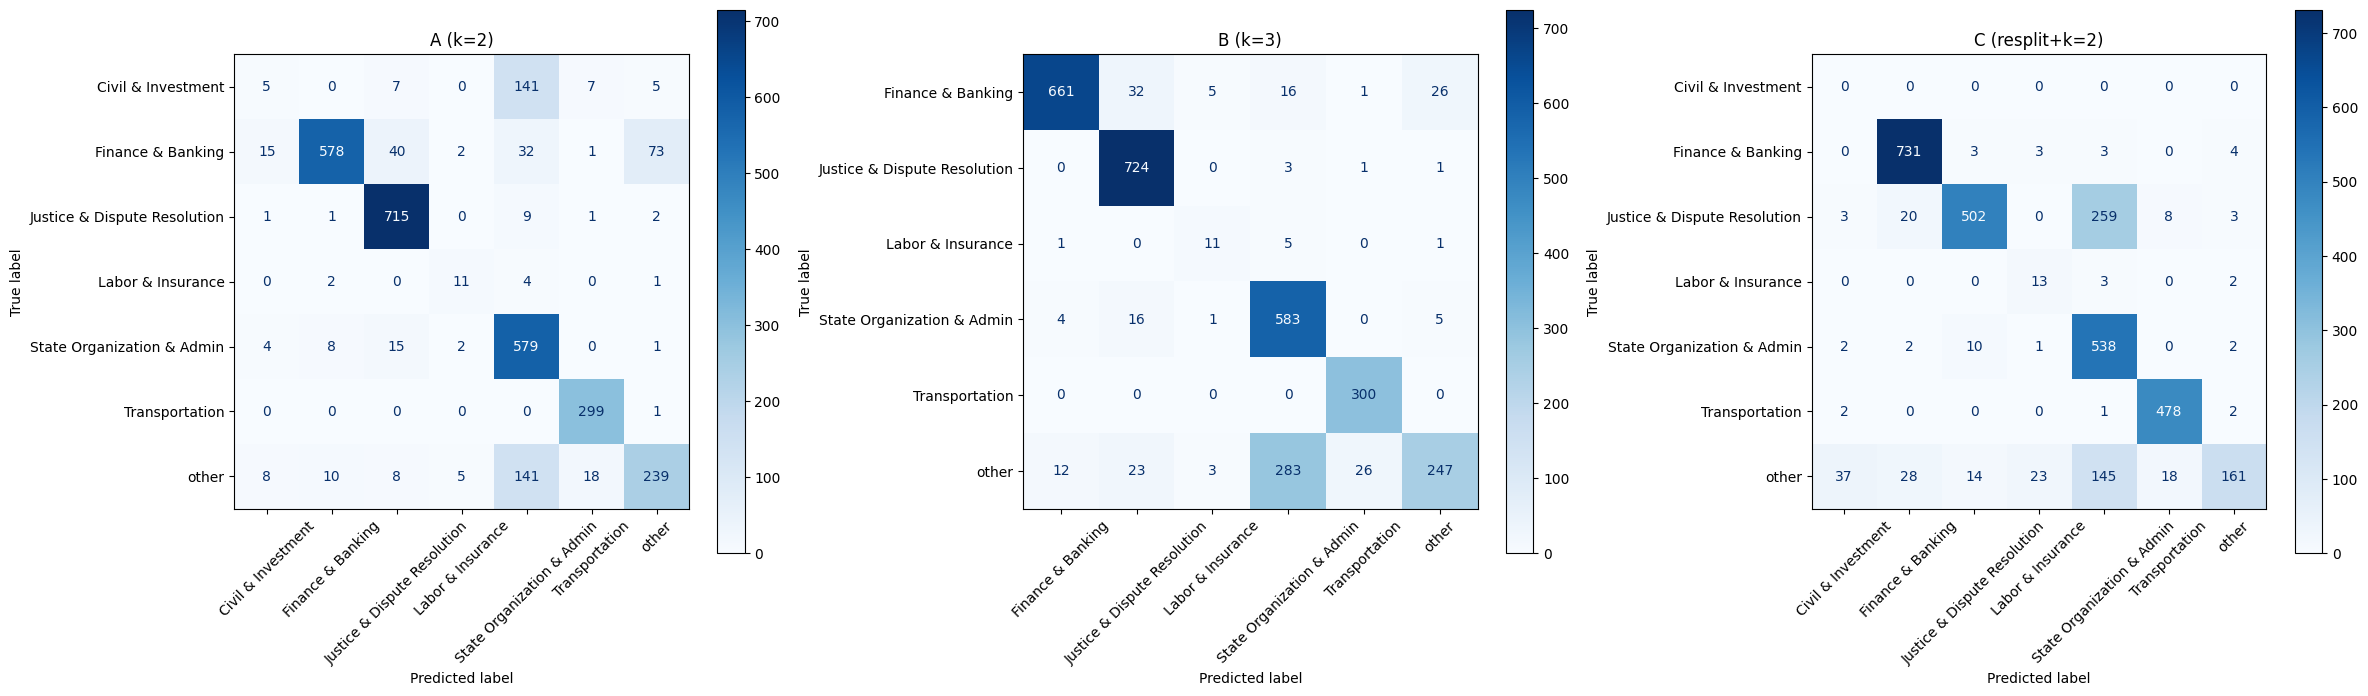

Saved: /kaggle/working/ablation_confusion_matrices.png


In [167]:
fig, axes = plt.subplots(1, len(results), figsize=(8 * len(results), 7))
if len(results) == 1:
    axes = [axes]

for ax, r in zip(axes, results):
    cm = confusion_matrix(r["y_true"], r["y_pred"], labels=list(range(r["num_classes"])))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=r["labels"])
    disp.plot(ax=ax, cmap="Blues", values_format="d", xticks_rotation=45)
    ax.set_title(r["name"])

plt.tight_layout()
plt.savefig(str(_out_dir / "ablation_confusion_matrices.png"), dpi=150)
plt.show()
print(f"Saved: {_out_dir / 'ablation_confusion_matrices.png'}")

## 'other' Class Analysis

In [168]:
for r in results:
    if "other" not in r["labels"]:
        continue
    other_idx = r["labels"].index("other")
    cm = confusion_matrix(r["y_true"], r["y_pred"], labels=list(range(r["num_classes"])))
    other_row = cm[other_idx]
    other_total = other_row.sum()

    print(f"\n--- {r['name']}: 'other' misclassification ---")
    if other_total == 0:
        print("  No 'other' samples in test set.")
        continue

    print(f"  Total 'other' test samples: {other_total}")
    print(f"  Correctly classified: {other_row[other_idx]} ({100*other_row[other_idx]/other_total:.1f}%)")
    print(f"  Misclassified as:")
    for i, count in enumerate(other_row):
        if count > 0 and i != other_idx:
            print(f"    -> {r['labels'][i]}: {count} ({100*count/other_total:.1f}%)")


--- A (k=2): 'other' misclassification ---
  Total 'other' test samples: 429
  Correctly classified: 239 (55.7%)
  Misclassified as:
    -> Civil & Investment: 8 (1.9%)
    -> Finance & Banking: 10 (2.3%)
    -> Justice & Dispute Resolution: 8 (1.9%)
    -> Labor & Insurance: 5 (1.2%)
    -> State Organization & Admin: 141 (32.9%)
    -> Transportation: 18 (4.2%)

--- B (k=3): 'other' misclassification ---
  Total 'other' test samples: 594
  Correctly classified: 247 (41.6%)
  Misclassified as:
    -> Finance & Banking: 12 (2.0%)
    -> Justice & Dispute Resolution: 23 (3.9%)
    -> Labor & Insurance: 3 (0.5%)
    -> State Organization & Admin: 283 (47.6%)
    -> Transportation: 26 (4.4%)

--- C (resplit+k=2): 'other' misclassification ---
  Total 'other' test samples: 426
  Correctly classified: 161 (37.8%)
  Misclassified as:
    -> Civil & Investment: 37 (8.7%)
    -> Finance & Banking: 28 (6.6%)
    -> Justice & Dispute Resolution: 14 (3.3%)
    -> Labor & Insurance: 23 (5.4%)
   